In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [11]:
!pip install scipy PyWavelets -q

import requests, io
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import scipy.io as iomat
import helpers
from TIMBRE import TIMBRE
import pywt

# --- Load data ---
#url = "https://api.figshare.com/v2/articles/24757638"
#files = requests.get(url).json()['files']
#f = next(x for x in files if x['name'] == 'data04.mat')
data = iomat.loadmat(io.BytesIO(requests.get(f['download_url']).content))

# --- Preprocess ---
LFPs = helpers.filter_data(data['lfps'], 2, fs=25, use_hilbert=True)
test_inds, train_inds = helpers.test_train(data['lapID'], which_phase=2, n_folds=5, which_fold=0)
wLFPs, U, Xv = helpers.whiten(LFPs, train_inds)
print(f"LFPs shape: {LFPs.shape}, electrodes: {LFPs.shape[1]}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
LFPs shape: (91710, 192), electrodes: 192


In [32]:
phase1 = np.where((data['lapID'][:, 3] == 1))
phase2 = np.where((data['lapID'][:, 3] == 2))

pc1_run = (LFPs[phase1] @ np.conj(U[0, :])).real
pc1_stay = (LFPs[phase2] @ np.conj(U[0, :])).real

In [31]:
LFPs[phase1].shape, LFPs[phase2].shape

((3938, 192), (35551, 192))

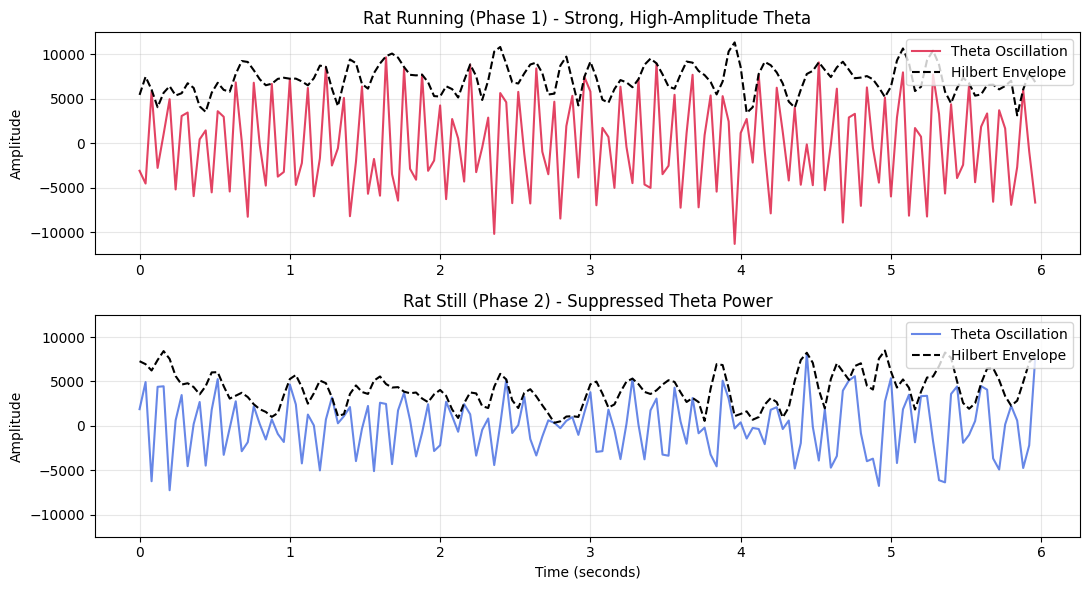

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Extract Complex Signals via Spatial Filter ---
# Because LFPs is complex, these projections will be complex arrays
complex_pc1_run = LFPs[phase1] @ np.conj(U[0, :])
complex_pc1_stay = LFPs[phase2] @ np.conj(U[0, :])

# --- 2. Extract Signal Components ---
# The real part gives the clean, filtered theta oscillations
theta_run = complex_pc1_run.real
theta_stay = complex_pc1_stay.real

# The magnitude (absolute value) gives the exact Hilbert amplitude envelope
env_run = np.abs(complex_pc1_run)
env_stay = np.abs(complex_pc1_stay)

# --- 3. Set Up Clean Time Axis ---
fs = 25  # Your sampling rate
window_size = 150  # 6 seconds of data (150 steps @ 25Hz) to see the cycles clearly
time_axis = np.arange(window_size) / fs

# --- 4. Plot ---
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharey=True)

# Plot Running Phase
axes[0].plot(time_axis, theta_run[:window_size], label='Theta Oscillation', color='crimson', alpha=0.8)
axes[0].plot(time_axis, env_run[:window_size], label='Hilbert Envelope', color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Rat Running (Phase 1) - Strong, High-Amplitude Theta', fontsize=12)
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot Staying Phase
axes[1].plot(time_axis, theta_stay[:window_size], label='Theta Oscillation', color='royalblue', alpha=0.8)
axes[1].plot(time_axis, env_stay[:window_size], label='Hilbert Envelope', color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Rat Still (Phase 2) - Suppressed Theta Power', fontsize=12)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
import pysindy as ps

In [55]:
A = np.abs(LFPs) # Ampliatude
phi = np.angle(LFPs) #Phase
phi_unwrapped = np.unwrap(phi)
A_log = np.log(A + 1e-10)

In [51]:
x_pos = data['lapID'][:,4]
y_pos = data['lapID'][:,5]

In [65]:
dx = np.diff(x_pos)
dy = np.diff(y_pos)
dt = 1 / 25 #25hz
speed = np.sqrt(dx**2 + dy**2) / dt
# pad to match length
speed = np.append(speed, speed[-1])

from scipy.ndimage import uniform_filter1d
speed_smooth = uniform_filter1d(speed, size=10)

In [69]:
X_state = np.column_stack([ # State: what SINDy finds equations FOR
    A_log,           # log amplitude
    phi_unwrapped,   # unwrapped phase
])

In [78]:
# Control: external inputs that modulate the dynamics
# Shape: (T, 4)

motion_label = np.where((data['lapID'][:,3] == 2) | (data['lapID'][:,3] == 0), 0, 1)


U_control = np.column_stack([
    motion_label.astype(float),   # binary still/moving
    speed_smooth,                 # continuous speed
    x_pos,                        # spatial x
    y_pos,                        # spatial y
])
 
feature_names  = ["log_A", "phi"]
control_names  = ["motion", "speed", "x", "y"]

In [92]:
# 5. BUILD LIBRARY

#   - polynomial terms from state variables
#   - Fourier (trig) terms from state variables
#   - cross terms between state and control
 
poly_lib    = ps.PolynomialLibrary(degree=2, include_bias=True)
#fourier_lib = ps.FourierLibrary(n_frequencies=2)  # sin/cos at 1x and 2x

# Combine polynomial and fourier over state variables
state_lib = ps.GeneralizedLibrary(
    [poly_lib, fourier_lib],
)

In [93]:
optimizer = ps.STLSQ(threshold=0.05, alpha=0.05)
# Optimizer: STLSQ (Sequential Threshold Least Squares)

# Differentiation: smoothed finite difference
# This is more noise-robust than raw finite differences
# for neural data
differentiator = ps.SmoothedFiniteDifference(
    smoother_kws={"window_length": 15})

In [94]:
model = ps.SINDy(
    optimizer=optimizer,
    differentiation_method=differentiator,
    feature_library=poly_lib,
    #feature_names=feature_names,
)
 
model.fit(
    X_state,
    u=U_control,
    t=dt,
    #quiet=True,
)
 
print("=== Discovered Equations ===")
model.print(lhs=["d(log_A)/dt", "d(phi)/dt"], precision=4)

KeyboardInterrupt: 

In [96]:
print(f"Timesteps: {X_state.shape[0]}")
print(f"Duration: {X_state.shape[0] * dt:.1f} seconds")
print(poly_lib)

Timesteps: 91710
Duration: 3668.4 seconds
PolynomialLibrary()


In [ ]:
print(f"X_state shape: {X_state.shape}")
print(f"U_control shape: {U_control.shape}")
print(f"Total features poly degree=2: {ps.PolynomialLibrary(degree=2).fit_transform(np.hstack([X_state, U_control])).shape[1]}")

X_state shape: (91710, 384)
U_control shape: (91710, 4)
